<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/03_DL_weight_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Weights Initialization(가중치 초기화)**
- 신경망 학습을 시작하기 전 각 뉴런의 초기 가중치 값을 설정하는 단계
- 초기값을 단순히 0으로 채우거나 너무 크거나 작게 설정하면, 역전파 과정에서 기인하는 기울기 소실(Vanishing Gradient)이나 기울기 폭주(Exploding Gradient) 현상이 발생
- 가중치를 무작위로 고르게 분포시키는 최적의 초기화 전략들이 도입
- **Xavier(Glorot)** 초기화는 Sigmoid나 Tanh와 같은 S자형 활성화 함수와 잘 맞으며
- TensorFlow 2.X 버전에서는 디폴트로 **Xavier** 초기화를 사용함.
- **He** 초기화는 현대 딥러닝에서 널리 쓰이는 ReLU 활성화 함수에 최적화


In [1]:
# 모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import tensorflow as tf

## **1. mnist data classification MLP modeling**
- 손글씨 이미지 데이터를 학습시켜 0~9까지의 손글씨 숫자를 구분하는 classification model
- 기존 모델과는 달리 output layer의 activation function에 softmax 적용
- compile에 loss/metrics를 'sparse_categorical_crossentropy'/'accuracy'로 변경

### **1.1 load data**

In [2]:
# load data
data = fetch_openml('mnist_784')

In [26]:
# target 데이터 분리
# print(data['DESCR'])
X = data['data'] / 255
y = data['target'].astype(int)

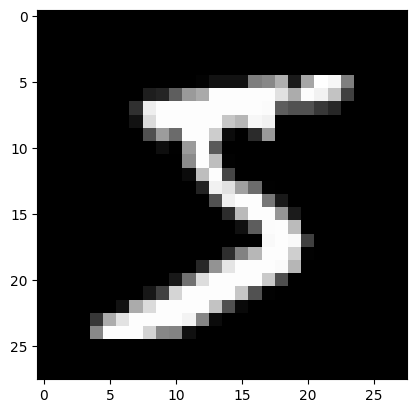

In [12]:
# X 데이터 확인
plt.imshow(X.iloc[0].values.reshape(28, 28), cmap='gray')

In [27]:
# 학습데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(56000, 784)

### **1.2 model structure**
- 예측모델과 분류모델의 구조 상 가장 큰 차이는 출력결과를 만들어 내는 output layer이다.
- 분류모델의 경우 출력결과를 타겟데이터인 y값의 고윳값 갯수만큼의 unit을 만들어 각 unit에서 출력되는 결과값이 해당 클래스로 분류할 확률값이 출력될 수 있게 설정한다.
- output layer의 activation function을 softmax로 설정하여 간단하게 적용한다.

In [16]:
# 모델 설계
# keras.models.Sequentail 객체에 모든 구조 할당
# 기본적으로 Xavier 초기화를 사용하기에 각 layer의 activation을 sigmoid로 설정
model1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    tf.keras.layers.Dense(units=128, activation='sigmoid'),
    tf.keras.layers.Dense(units=64, activation='sigmoid'),
    tf.keras.layers.Dense(units=16, activation='sigmoid'),
    tf.keras.layers.Dense(units=10, activation='softmax', name='out')
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,946 (429.48 KB)

 Trainable params: 109,946 (429.48 KB)

 Non-trainable params: 0 (0.00 B)

### **1.3 compile**
- 분류모델의 compile은 예측과 달리 loss/metrics 설정을 변경해주어야 작동
- metrics는 분류모델을 평가 하기위한 accuracy 설정
- loss는 sparse_categorical_crossentropy를 설정

Tensorflow 공식 docs : https://www.tensorflow.org/api_docs/python/tf/keras/metrics

In [17]:
# 모델 compile keras 객체 사용
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=[tf.keras.metrics.Accuracy]
)

### **1.4 모델 학습 후 학습곡선 확인**

Epoch 1/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0000e+00 - loss: 0.9219 - val_accuracy: 0.0000e+00 - val_loss: 0.3732
Epoch 2/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0000e+00 - loss: 0.2711 - val_accuracy: 0.0000e+00 - val_loss: 0.2157
Epoch 3/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.1723 - val_accuracy: 0.0000e+00 - val_loss: 0.1985
Epoch 4/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.1274 - val_accuracy: 0.0000e+00 - val_loss: 0.1444
Epoch 5/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0981 - val_accuracy: 0.0000e+00 - val_loss: 0.1241
Epoch 6/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0779 - val_accuracy: 0.0000e+00 - val_loss: 0.1196
Epoch 7/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0639 - val_accuracy: 0.0000e+00 - val_loss: 0.1131
Epoch 8/50
1400/1400 ━━━━━━━━━━━━

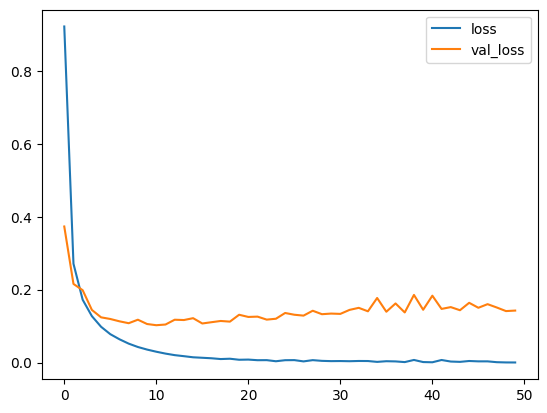

In [28]:
# 모델 학습 후 학습곡선 시각화
history = model1.fit(X_train, y_train, epochs=50, validation_split=0.2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

## **2. Xavier initializer 설정**
- 이전 레이어의 노드 수($n_{in}$)와 다음 레이어의 노드 수($n_{out}$)를 고려, 가중치의 초깃값 분산을 노드 갯수에 반비례하게 $\text{Var}(W) = \frac{2}{n_{in} + n_{out}}$ 설정
- 초기화 된 weights의 값의 분포가 uniform(균등분포)하게 설정

$$\text{Var}(U(-a, +a)) = \frac{(최댓값 - 최솟값)^2}{12} = \frac{(a - (-a))^2}{12} = \frac{(2a)^2}{12} = \frac{4a^2}{12} = \frac{a^2}{3}$$
$$\frac{a^2}{3} = \frac{2}{n_{in} + n_{out}}$$
$$a^2 = \frac{6}{n_{in} + n_{out}}$$
$$a = \sqrt{\frac{6}{n_{in} + n_{out}}}$$

a: 경계값 즉, -a ~ +a 까지의 범위값

- 이전 층에서 들어온 데이터의 퍼진 정도(분산)와, 현재 층이 계산해서 다음 층으로 보낼 데이터의 퍼진 정도(분산)를 동일하게
- 앞뒤 레이어 간의 정보 흐름이 왜곡 없이 균등하게 전달
- 선형성을 가정한 sigmoid 나 tanh 같은 활성화 함수를 사용할 때 발생하는 기울기 소실(Vanishing Gradient) 문제를 효과적으로 억제하고 안정적인 초기 학습이 가능
- 단, 최근 딥러닝 모델의 표준으로 사용하는 Relu 활성화 함수의 경우 음수의 영역을 0으로 만들기에 레이어가 깊어질 수록 전달되는 값이 반토막이 남 0으로 수렴

In [30]:
# Xavier glorot_uniform 적용
# model 2 clone 후 각 레이어에 문자열, 초기화 객체 사용하여 초기화 적용
# kernel_initializer='glorot_uniform'
# kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)
tf.random.set_seed(42)

model2 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    # 문자열 적용
    tf.keras.layers.Dense(
        units=128,
        activation='sigmoid',
        kernel_initializer='glorot_uniform'
    ),
    # 객체 전달
    tf.keras.layers.Dense(
        units=64,
        activation='sigmoid',
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)
        ),
    # 디폴트
    tf.keras.layers.Dense(units=16, activation='sigmoid'),

    tf.keras.layers.Dense(units=10, activation='softmax', name='out')
])
# tf에서는 기본적으로 Xavier 초기화 사용
# 다만 sigmoid activation 사용 시 명시적으로 kernel_initializer 적어주시는 것이 좋음
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=[tf.keras.metrics.Accuracy]
)

Epoch 1/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.0000e+00 - loss: 0.9052 - val_accuracy: 0.0000e+00 - val_loss: 0.3834
Epoch 2/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.2840 - val_accuracy: 0.0000e+00 - val_loss: 0.2206
Epoch 3/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1778 - val_accuracy: 0.0000e+00 - val_loss: 0.1656
Epoch 4/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.1280 - val_accuracy: 0.0000e+00 - val_loss: 0.1412
Epoch 5/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0977 - val_accuracy: 0.0000e+00 - val_loss: 0.1255
Epoch 6/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0769 - val_accuracy: 0.0000e+00 - val_loss: 0.1157
Epoch 7/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0613 - val_accuracy: 0.0000e+00 - val_loss: 0.1088
Epoch 8/20
1400/1400 ━━━━━━━━━━━━

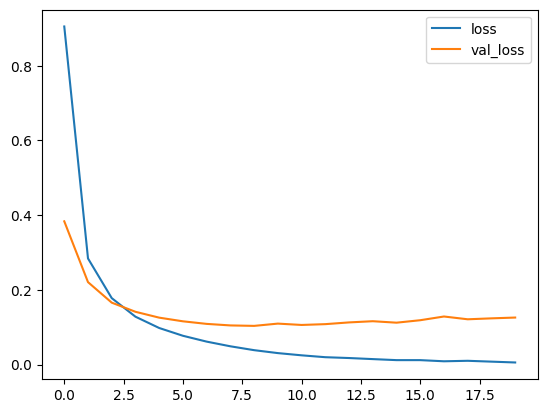

In [31]:
# 모델 학습 후 history 시각화
history2 = model2.fit(X_train, y_train, epochs=20, validation_split=0.2)
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

## **2. He initializer 설정**
- sigmoid 대신 ReLU 활성화 함수를 사용할 때 발생하는 기울기 소실 문제를 해결하기 위해 도입된 가중치 초기화 기법
- ReLU는 입력값이 0 이하일 때 출력을 0으로 만듬, Xavier 초기화 적용 시 레이어를 거칠 때마다 데이터의 분산이 절반씩 줄어듬
- 가중치의 분산을 자비에보다 2배 더 키운 $\frac{2}{n_{in}}$로 설정하여, 출력 데이터의 퍼진 정도를 건강하게 유지
- kernel_initializer='he_uniform'으로 설정
- $[- \sqrt{\frac{6}{n_{in}}}, \ + \sqrt{\frac{6}{n_{in}}} ]$ 범위 내에서 실제 가중치 값들을 무작위로 설정


In [32]:
# he_uniform 적용
# model3 clone 후 각 레이어에 문자열, 초기화 객체 사용하여 초기화 적용
# kernel_initializer='he_uniform'
# kernel_initializer=tf.keras.initializers.HeUniform(seed=42)
tf.random.set_seed(42)

model3 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    # 문자열 적용
    tf.keras.layers.Dense(
        units=128,
        activation='relu',
        kernel_initializer='he_uniform',
    ),
    # 객체 전달
    tf.keras.layers.Dense(
        units=64,
        activation='relu',
        kernel_initializer=tf.keras.initializers.HeUniform(seed=42),
        ),
    # 디폴트
    tf.keras.layers.Dense(
        units=16,
        activation='relu',
        kernel_initializer=tf.keras.initializers.HeUniform(seed=42),
        ),

    tf.keras.layers.Dense(units=10, activation='softmax', name='out')
])
# tf에서는 기본적으로 Xavier 초기화 사용
# 다만 sigmoid activation 사용 시 명시적으로 kernel_initializer 적어주시는 것이 좋음
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=[tf.keras.metrics.Accuracy]
)

Epoch 1/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.0000e+00 - loss: 0.3059 - val_accuracy: 0.0000e+00 - val_loss: 0.1915
Epoch 2/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.1201 - val_accuracy: 0.0000e+00 - val_loss: 0.1360
Epoch 3/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0828 - val_accuracy: 0.0000e+00 - val_loss: 0.1318
Epoch 4/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0611 - val_accuracy: 0.0000e+00 - val_loss: 0.1240
Epoch 5/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0464 - val_accuracy: 0.0000e+00 - val_loss: 0.1263
Epoch 6/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0374 - val_accuracy: 0.0000e+00 - val_loss: 0.1248
Epoch 7/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0344 - val_accuracy: 0.0000e+00 - val_loss: 0.1343
Epoch 8/20
1400/1400 ━━━━━━━━━━━━

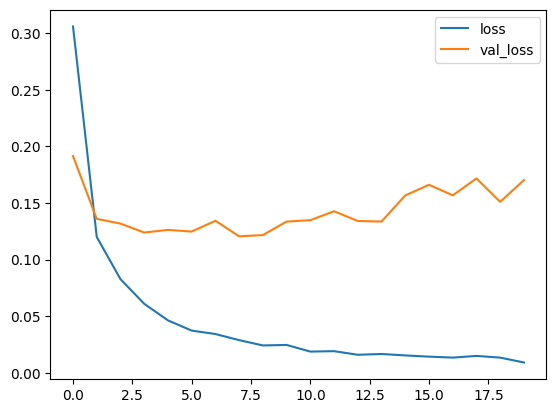

In [33]:
# 모델 학습 후 history 시각화
history3 = model3.fit(X_train, y_train, epochs=20, validation_split=0.2)
plt.plot(history3.history['loss'], label='loss')
plt.plot(history3.history['val_loss'], label='val_loss')
plt.legend()
plt.show()